# NYC Yellow Taxi — Analytical Results

Visualizations of the marts built with dbt and DuckDB
for the DSCOVR challenge, using July 2026 trip data.

In [12]:
import sys
print(sys.executable)

import duckdb
print(duckdb.__version__)

c:\Users\homeyra.mahmoudi\github\duckdb-dbt-challenge\.venv\Scripts\python.exe
1.5.6


In [13]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

db_path = project_root / "data" / "db" / "yellow_tripdata.duckdb"

if not db_path.is_file():
    raise FileNotFoundError(f"Database not found: {db_path}")

con = duckdb.connect(str(db_path), read_only=True)

In [14]:
time_of_day = con.sql("""
    select time_of_day, total_trips, total_revenue
    from mart_trips_by_time_of_day
    order by case time_of_day
        when 'morning' then 1
        when 'afternoon' then 2
        when 'evening' then 3
        when 'night' then 4
    end
""").df()

time_of_day

,time_of_day,total_trips,total_revenue
0,morning,783098,22975159.42
1,afternoon,973005,30146663.99
2,evening,1096021,32945496.90
3,night,662677,20427685.44


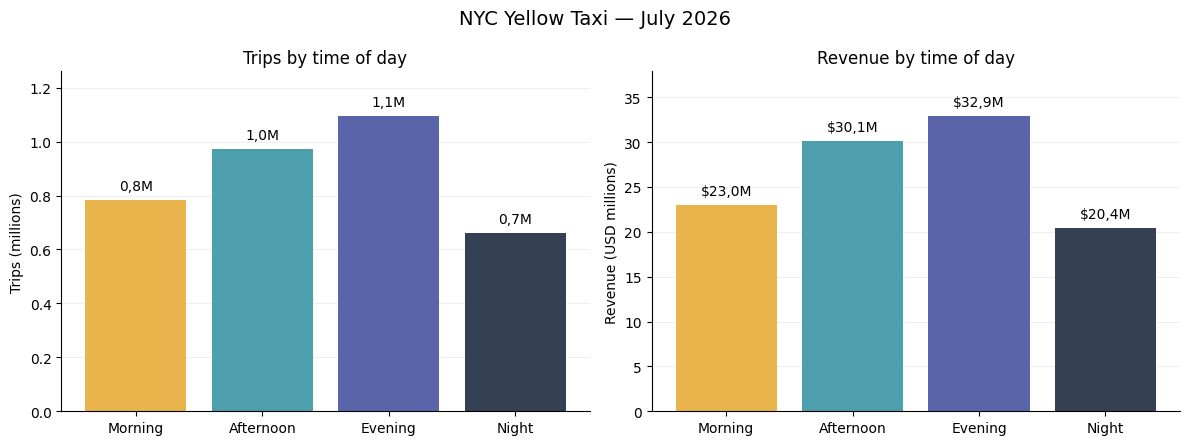

In [ ]:
from matplotlib.ticker import FuncFormatter

labels = time_of_day["time_of_day"].str.title()
colors = ["#E9B44C", "#4E9FAD", "#5965A8", "#344054"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(labels, time_of_day["total_trips"], color=colors)
axes[0].set_title("Trips by time of day")
axes[0].set_ylabel("Trips (millions)")
axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value / 1_000_000:.1f}")
)

axes[1].bar(labels, time_of_day["total_revenue"], color=colors)
axes[1].set_title("Revenue by time of day")
axes[1].set_ylabel("Revenue (USD millions)")
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value / 1_000_000:.0f}")
)

for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("July 2026 Trips vs Revenue", fontsize=14)

axes[0].bar_label(
    axes[0].containers[0],
    labels=[
        f"{value / 1_000_000:.1f}M".replace(".", ",")
        for value in time_of_day["total_trips"]
    ],
    padding=5,
    fontsize=10,
)

axes[1].bar_label(
    axes[1].containers[0],
    labels=[
        f"${value / 1_000_000:.1f}M".replace(".", ",")
        for value in time_of_day["total_revenue"]
    ],
    padding=5,
    fontsize=10,
)

# Leave room above the bars for the labels.
for ax in axes:
    ax.margins(y=0.15)

fig.tight_layout()

# Save the figure for inclusion in the README.
output_dir = project_root / "docs" / "images"
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / "trips_and_revenue_by_time_of_day.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

Evening has the highest trip count and total revenue.
Time categories are based on pickup time. All cleaned staging
records are included, regardless of duration-quality status.

Leggere iL mart 

In [16]:
top_zones = con.sql("""
    select pickup_location_id, total_trips, total_revenue
    from mart_top_pickup_zones
    order by total_trips desc, pickup_location_id
""").df()

top_zones

,pickup_location_id,total_trips,total_revenue
0,161,152110,4134513.26
1,132,149885,11765666.40
2,237,139876,3073613.81
3,236,118129,2690448.68
4,186,117287,3181219.43


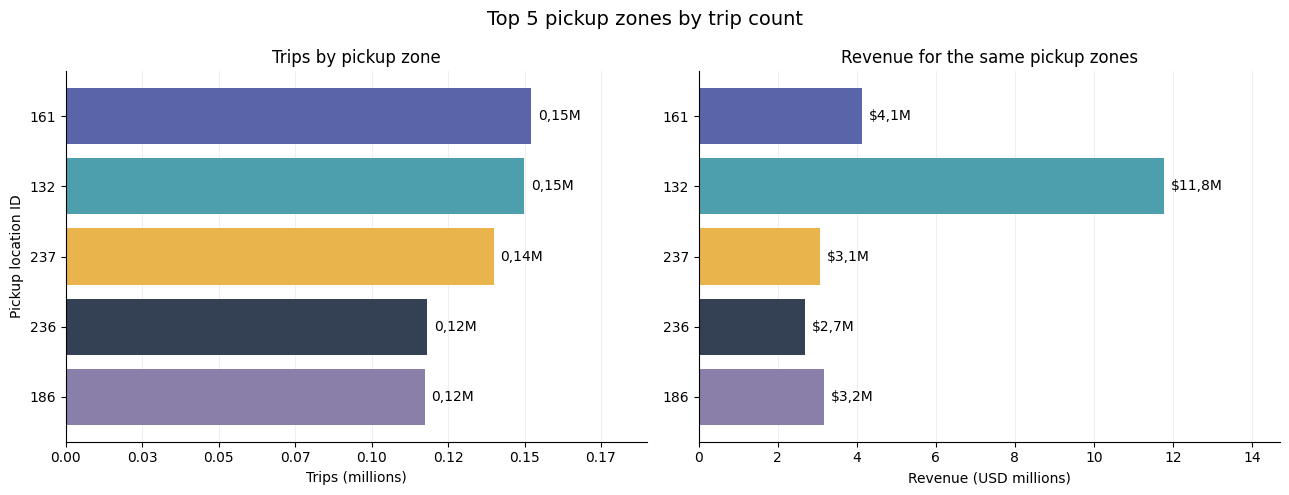

In [22]:
zone_labels = top_zones["pickup_location_id"].astype(str)
zone_colors = ["#5965A8", "#4E9FAD", "#E9B44C", "#344054", "#8A7FA8"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(
    zone_labels,
    top_zones["total_trips"],
    color=zone_colors,
)
axes[0].set_title("Trips by pickup zone")
axes[0].set_xlabel("Trips (millions)")
axes[0].set_ylabel("Pickup location ID")
axes[0].xaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value / 1_000_000:.2f}")
)
axes[0].bar_label(
    axes[0].containers[0],
    labels=[
        f"{value / 1_000_000:.2f}M".replace(".", ",")
        for value in top_zones["total_trips"]
    ],
    padding=5,
)

axes[1].barh(
    zone_labels,
    top_zones["total_revenue"],
    color=zone_colors,
)
axes[1].set_title("Revenue for the same pickup zones")
axes[1].set_xlabel("Revenue (USD millions)")
axes[1].xaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value / 1_000_000:.0f}")
)
axes[1].bar_label(
    axes[1].containers[0],
    labels=[
        f"${value / 1_000_000:.1f}M".replace(".", ",")
        for value in top_zones["total_revenue"]
    ],
    padding=5,
)

for ax in axes:
    ax.invert_yaxis()
    ax.margins(x=0.25)
    ax.set_axisbelow(True)
    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Top 5 pickup zones by trip count",
    fontsize=14,
)
fig.tight_layout()

fig.savefig(
    output_dir / "top_pickup_zones.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

Zone 161 has the most trips, while zone 132 generates the highest
revenue among these five zones.

Zones are selected by trip count. The revenue chart shows the
same selection, rather than an independent top five by revenue.

leggere il mart

In [18]:
distance_analysis = con.sql("""
    select
        distance_category,
        total_trips,
        avg_trip_duration_minutes,
        total_revenue
    from mart_distance_analysis
    order by case distance_category
        when 'short' then 1
        when 'medium' then 2
        when 'long' then 3
    end
""").df()

distance_analysis

,distance_category,total_trips,avg_trip_duration_minutes,total_revenue
0,short,1793129,10.66,35865001.82
1,medium,1003031,19.29,29072883.44
2,long,676336,33.03,40418447.72


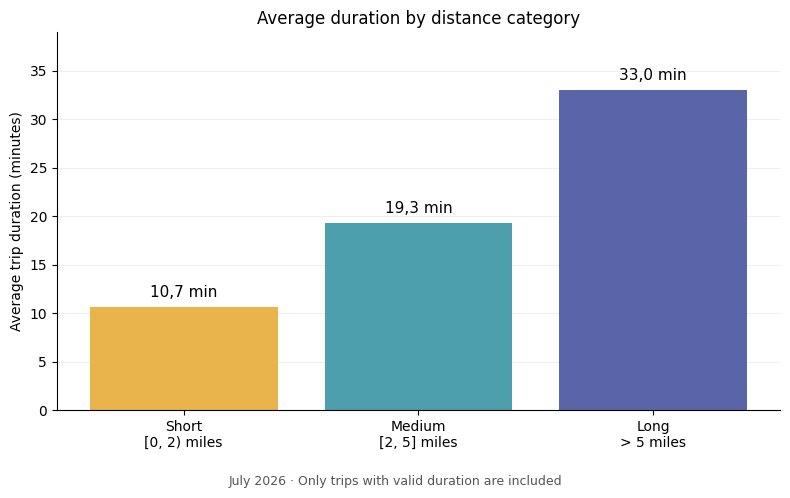

In [21]:
labels = ["Short\n[0, 2) miles", "Medium\n[2, 5] miles", "Long\n> 5 miles"]
colors = ["#E9B44C", "#4E9FAD", "#5965A8"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    distance_analysis["avg_trip_duration_minutes"],
    color=colors,
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f} min".replace(".", ",")
        for value in distance_analysis["avg_trip_duration_minutes"]
    ],
    padding=5,
    fontsize=11,
)

ax.set_title("Average duration by distance category")
ax.set_ylabel("Average trip duration (minutes)")
ax.margins(y=0.18)
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)

fig.text(
    0.5,
    0.02,
    "July 2026 · Only trips with valid duration are included",
    ha="center",
    fontsize=9,
    color="#555555",
)

fig.tight_layout(rect=[0, 0.06, 1, 1])

fig.savefig(
    output_dir / "average_duration_by_distance.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

Average trip duration increases with distance category:
approximately 10.7 minutes for short trips, 19.3 for medium trips,
and 33.0 for long trips.

Only records classified as `valid` by `duration_quality_status`
are included. Zero and negative durations remain in staging
for monitoring but are excluded from this analysis.

In [20]:
con.close()